<a href="https://colab.research.google.com/github/pxtroniwnl/Akinator-Futbol-ML/blob/main/dr_copper_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install yfinance

/tmp/ipykernel_5810/395961205.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="1990-01-01", end="2026-04-18")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
[*********************100%***********************]  1 of 1 completed


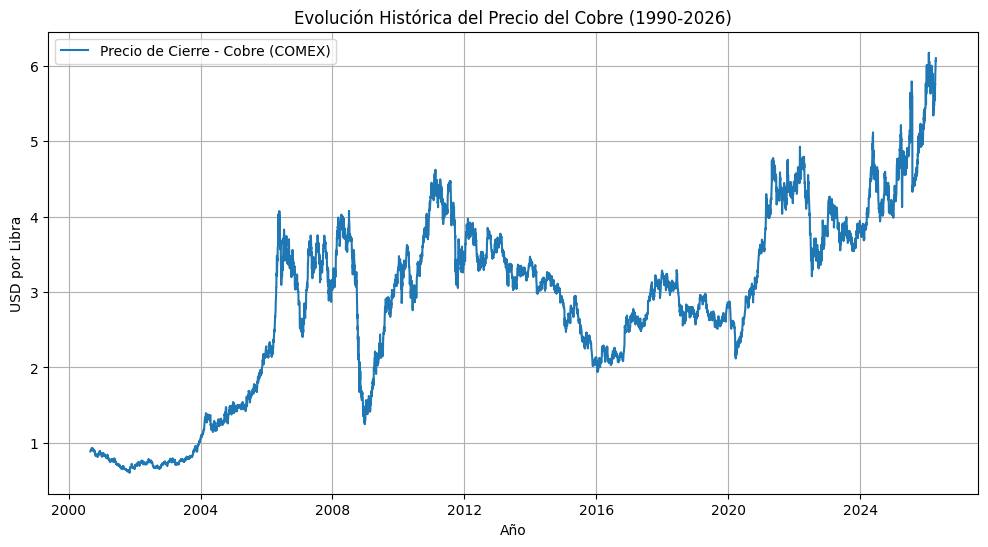


--- Prueba Dickey-Fuller Aumentada ---
Estadístico ADF: -1.0603
p-value: 0.7307
Resultado: La serie NO es estacionaria (No rechaza H0)


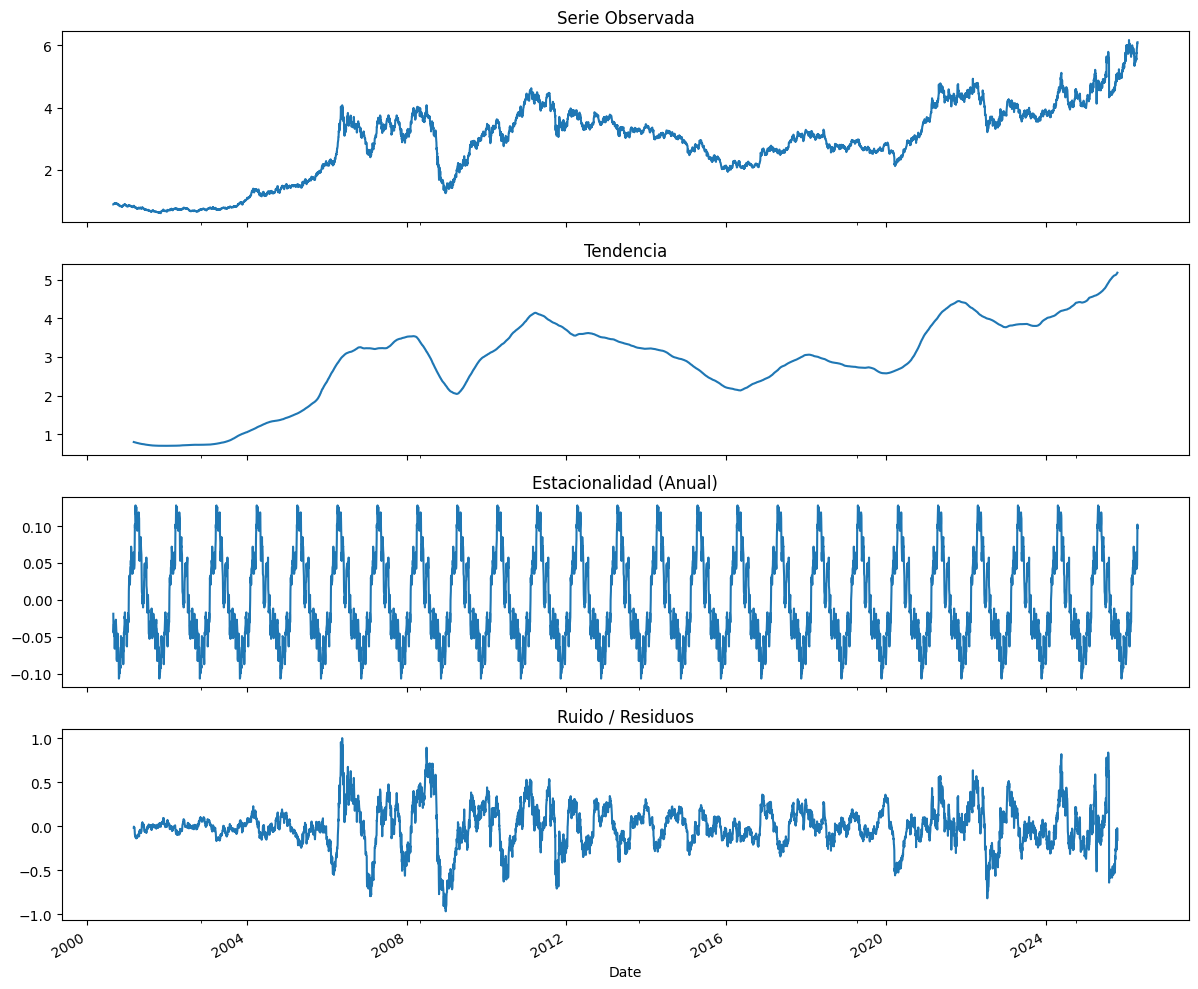

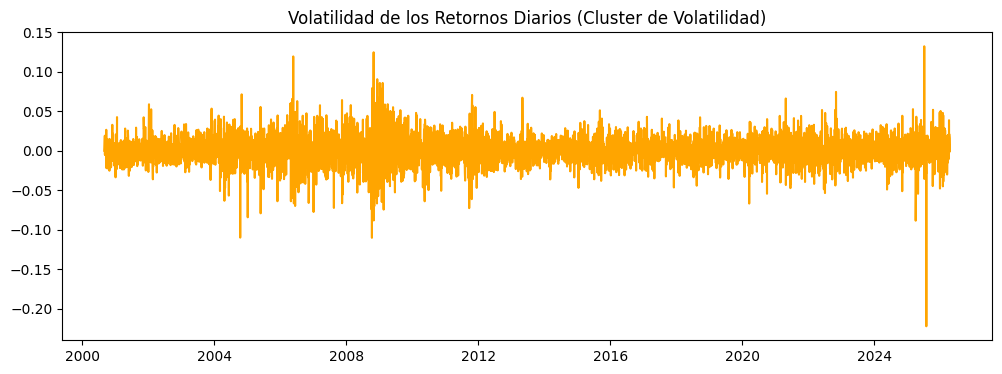

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Extracción de Datos (Mínimo 30 años)
ticker = "HG=F"
df = yf.download(ticker, start="1990-01-01", end="2026-04-18")

# Limpieza básica
df = df['Close'].dropna()

# 2. Visualización de la Serie Original
plt.figure(figsize=(12, 6))
plt.plot(df, label='Precio de Cierre - Cobre (COMEX)')
plt.title('Evolución Histórica del Precio del Cobre (1990-2026)')
plt.xlabel('Año')
plt.ylabel('USD por Libra')
plt.grid(True)
plt.legend()
plt.show()

# 3. Prueba de Estacionariedad (Dickey-Fuller Aumentada)
def ejecutar_adf(serie):
    result = adfuller(serie)
    print('\n--- Prueba Dickey-Fuller Aumentada ---')
    print(f'Estadístico ADF: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Resultado: La serie es ESTACIONARIA (Rechaza H0)")
    else:
        print("Resultado: La serie NO es estacionaria (No rechaza H0)")

ejecutar_adf(df)

# 4. Descomposición de Componentes
# Nota: Como es serie diaria, usamos un periodo de 252 (días hábiles en un año)
res = seasonal_decompose(df, model='additive', period=252)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
res.observed.plot(ax=ax1, title='Serie Observada')
res.trend.plot(ax=ax2, title='Tendencia')
res.seasonal.plot(ax=ax3, title='Estacionalidad (Anual)')
res.resid.plot(ax=ax4, title='Ruido / Residuos')
plt.tight_layout()
plt.show()

# 5. Análisis de Retornos (Para modelado futuro)
retornos = df.pct_change().dropna()
plt.figure(figsize=(12, 4))
plt.plot(retornos, color='orange')
plt.title('Volatilidad de los Retornos Diarios (Cluster de Volatilidad)')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import kpss

def ejecutar_kpss(serie):
    result = kpss(serie, regression='c')
    print('\n--- Prueba KPSS ---')
    print(f'Estadístico KPSS: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    # H0 para KPSS es que la serie es estacionaria. Rechazamos H0 si p-value < alpha (0.05)
    if result[1] < 0.05:
        print("Resultado: La serie NO es estacionaria (Rechaza H0)")
    else:
        print("Resultado: La serie es ESTACIONARIA (No rechaza H0)")

ejecutar_kpss(df)


--- Prueba KPSS ---
Estadístico KPSS: 6.6443
p-value: 0.0100
Resultado: La serie NO es estacionaria (Rechaza H0)


/tmp/ipykernel_5810/3419887729.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  result = kpss(serie, regression='c')


In [ ]:
df_diferenciada = df.diff().dropna()

print("\n--- Pruebas de Estacionariedad para la Serie Diferenciada ---")
ejecutar_adf(df_diferenciada)
ejecutar_kpss(df_diferenciada)


--- Pruebas de Estacionariedad para la Serie Diferenciada ---

--- Prueba Dickey-Fuller Aumentada ---
Estadístico ADF: -17.6011
p-value: 0.0000
Resultado: La serie es ESTACIONARIA (Rechaza H0)

--- Prueba KPSS ---
Estadístico KPSS: 0.0798
p-value: 0.1000
Resultado: La serie es ESTACIONARIA (No rechaza H0)


/tmp/ipykernel_5810/3419887729.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(serie, regression='c')


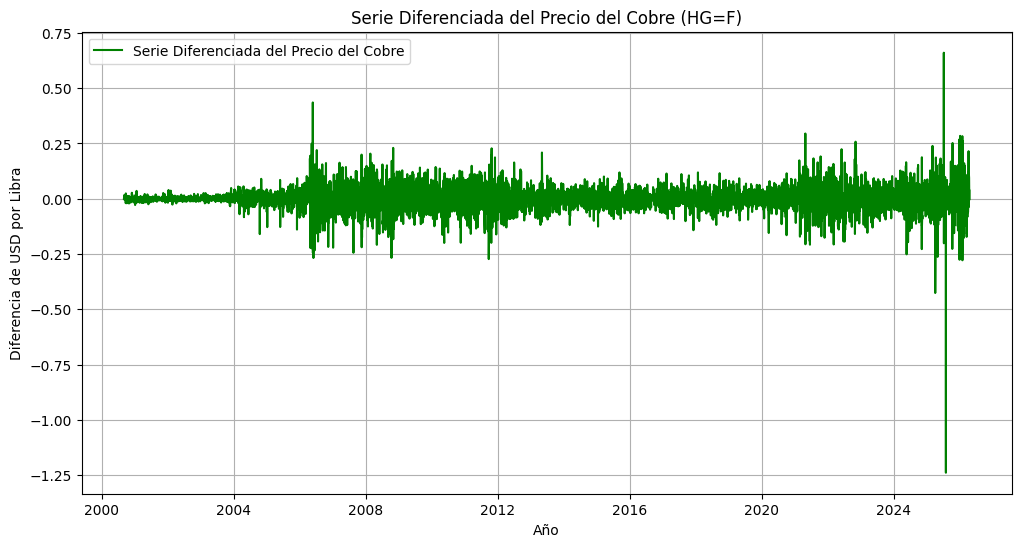

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_diferenciada, label='Serie Diferenciada del Precio del Cobre', color='green')
plt.title('Serie Diferenciada del Precio del Cobre (HG=F)')
plt.xlabel('Año')
plt.ylabel('Diferencia de USD por Libra')
plt.grid(True)
plt.legend()
plt.show()

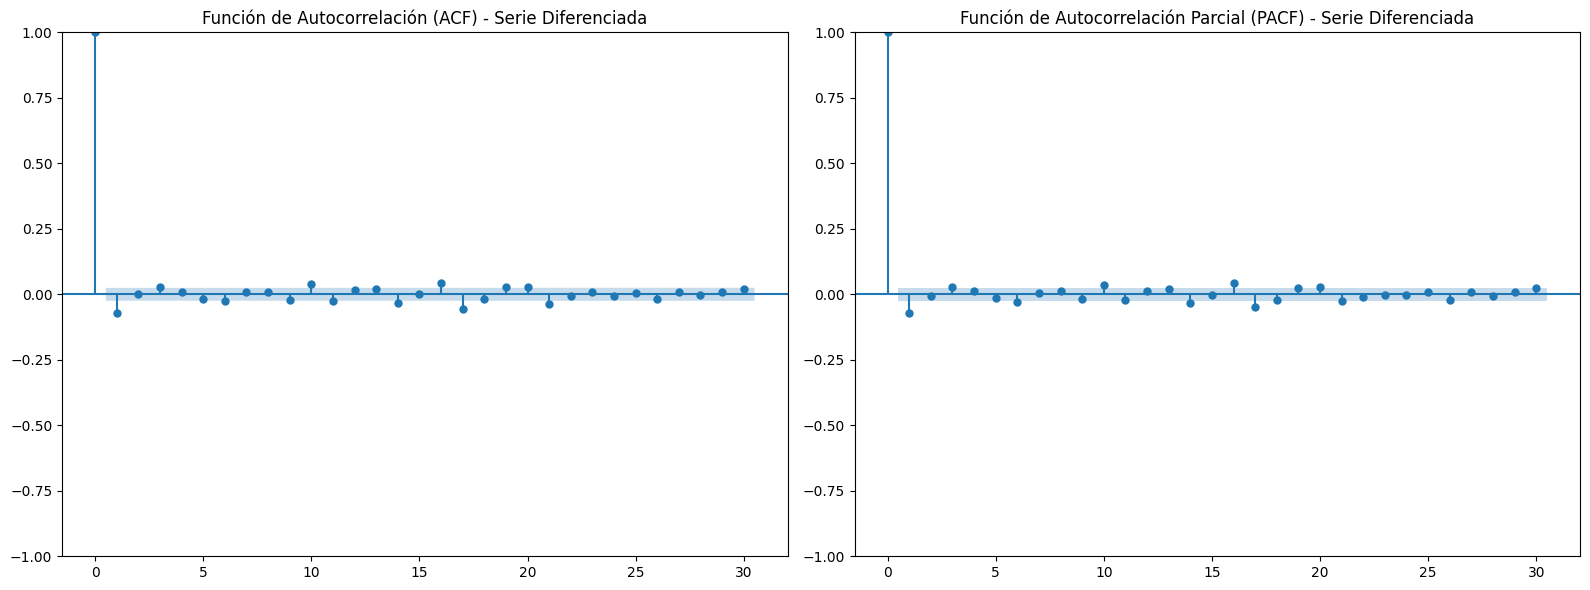

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_acf(df_diferenciada, lags=30, ax=axes[0], title='Función de Autocorrelación (ACF) - Serie Diferenciada')
plot_pacf(df_diferenciada, lags=30, ax=axes[1], title='Función de Autocorrelación Parcial (PACF) - Serie Diferenciada')

plt.tight_layout()
plt.show()

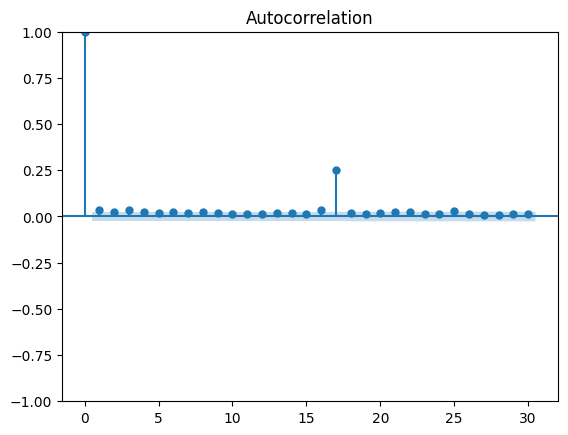

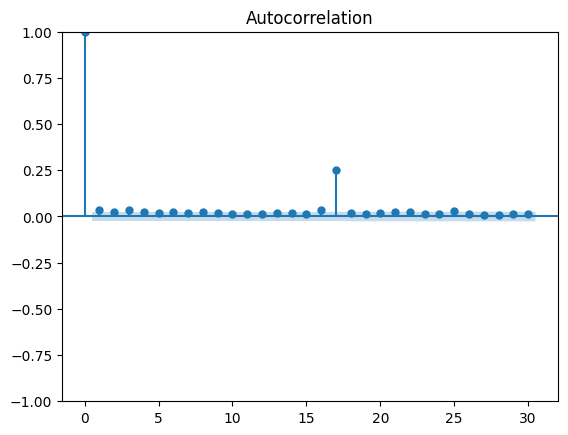

In [ ]:
plot_acf(df_diferenciada**2, lags=30)